# How well do jobs and skills pay for Data Analysts?

## Methodology

1. Evaluate median salary for top 6 data jobs  
2. Find median salary per skill for Data Analysts  
3. Visualize for highest paying skills and most demanded skills  

In [1]:
# Importing libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_IND = df[(df['job_country'] == 'India')].dropna(subset=['salary_year_avg'])

In [5]:
df_titles = df_IND['job_title_short'].value_counts().index[:6].tolist()

In [6]:
df_IND_top6 = df_IND[df_IND['job_title_short'].isin(df_titles)]

In [10]:
job_order = df_IND_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

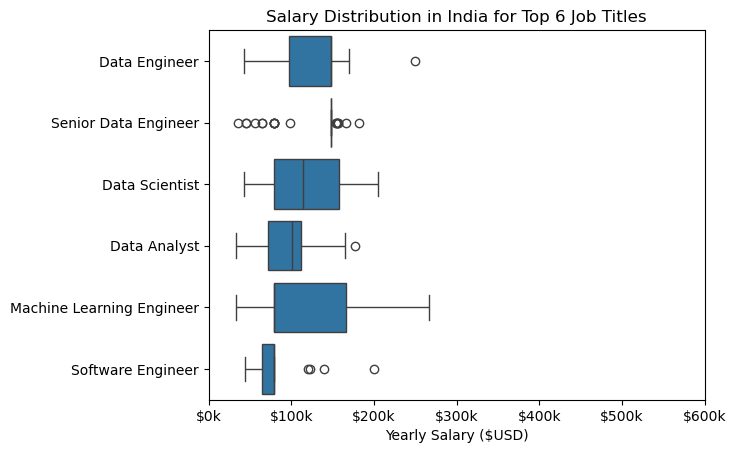

In [11]:
sns.boxplot(data=df_IND_top6, x='salary_year_avg', y='job_title_short', order=job_order)
plt.title('Salary Distribution in India for Top 6 Job Titles')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
ax = plt.gca()
ticks_x = plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0, 600000)
plt.show()